# Classify CLOSED/OPEN EYE with Keras and MobileNet

## Step 1: Data Preprocessing

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

DATASET_PATH = "dataset/eye-dataset/"  # Included 3 folders: train, val, test
IMG_SIZE = 128 #Change: Increase IMG_SIZE        
BATCH_SIZE = 96 #Change: Increase BATCH_SIZE

# 1. Load Training
train_ds = tf.keras.utils.image_dataset_from_directory(
  os.path.join(DATASET_PATH, 'train'),
  seed=42,
  image_size=(IMG_SIZE, IMG_SIZE),
  batch_size=BATCH_SIZE)

# 2. Load Validation
val_ds = tf.keras.utils.image_dataset_from_directory(
  os.path.join(DATASET_PATH, 'val'),
  seed=42,
  image_size=(IMG_SIZE, IMG_SIZE),
  batch_size=BATCH_SIZE)

# 3. Load Test
test_ds = tf.keras.utils.image_dataset_from_directory(
  os.path.join(DATASET_PATH, 'test'),
  seed=42,
  image_size=(IMG_SIZE, IMG_SIZE),
  batch_size=BATCH_SIZE)

class_names = train_ds.class_names
print(f"\nList of Labels found by Keras: {class_names}")

Found 139804 files belonging to 2 classes.
Found 27961 files belonging to 2 classes.
Found 6991 files belonging to 2 classes.

List of Labels found by Keras: ['closed', 'open']


In [4]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))


## Step 2: Load the MobileNetV2 Structure

In [5]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Transfer Learning:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

# Unfreeze the last 20 layers to learn the fine details of "Eyelashes" and "Irises"
for layer in base_model.layers[-20:]:
    layer.trainable = True

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x) ##Change: 0.4 -> 0.5
x = Dense(32, activation='relu', kernel_regularizer=l2(0.01))(x) ##Change: Add L2
outputs = Dense(1, activation='sigmoid')(x) # sigmoid since the output is binary: 0 or 1

model = Model(inputs, outputs)

model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        40,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,299,009 (8.77 MB)

 Trainable params: 1,247,105 (4.76 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

## Step 3: Do Training Model

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_blink_mobilenet.h5", save_best_only=True)

EPOCHS = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9513 - loss: 0.5308

1457/1457 ━━━━━━━━━━━━━━━━━━━━ 260s 177ms/step - accuracy: 0.9713 - loss: 0.3387 - val_accuracy: 0.9077 - val_loss: 0.3757
Epoch 2/10
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.9844 - loss: 0.0920

1457/1457 ━━━━━━━━━━━━━━━━━━━━ 239s 164ms/step - accuracy: 0.9867 - loss: 0.0710 - val_accuracy: 0.9807 - val_loss: 0.0672
Epoch 3/10
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.9899 - loss: 0.0374

1457/1457 ━━━━━━━━━━━━━━━━━━━━ 239s 164ms/step - accuracy: 0.9917 - loss: 0.0313 - val_accuracy: 0.9772 - val_loss: 0.0662
Epoch 4/10
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.9941 - loss: 0.0216

1457/1457 ━━━━━━━━━━━━━━━━━━━━ 232s 159ms/step - accuracy: 0.9949 - loss: 0.0192 - val_accuracy: 0.9819 - val_loss: 0.0627
Epoch 5/10
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 240s 165ms/step - accuracy: 0.9966 - loss: 0.0136 - val_accuracy: 0.9800 - val_loss: 0.0649
Epoch 6/10
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 238s 164ms/step - accuracy: 0.9973 - loss: 0.0109 - val_accuracy: 0.9829 - val_loss: 0.0705
Epoch 7/10
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 237s 163ms/step - accuracy: 0.9976 - loss: 0.0096 - val_accuracy: 0.9067 - val_loss: 0.5165
Epoch 8/10
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 231s 158ms/step - accuracy: 0.9978 - loss: 0.0090 - val_accuracy: 0.9822 - val_loss: 0.0882


## Step 4: Evaluation

73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.9825 - loss: 0.0600

Last Accuracy on Test: 98.25%


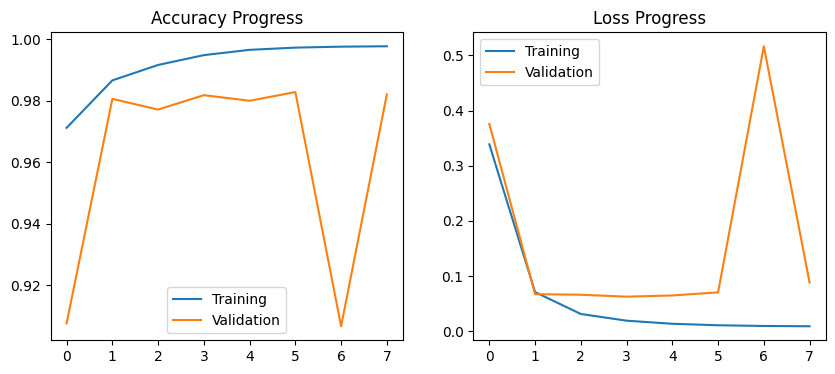

In [7]:
loss, acc = model.evaluate(test_ds)
print(f"\nLast Accuracy on Test: {acc*100:.2f}%")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy Progress')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss Progress')
plt.legend()
plt.show()

## Bước 5: Sang số, vác Model đi thực chiến (ONNX Export)

In [8]:
import tf2onnx

spec = (tf.TensorSpec((None, IMG_SIZE, IMG_SIZE, 3), tf.float32, name="input"),)
output_path = "mobilenet_eye_blink.onnx"

model_proto, _ = tf2onnx.convert.from_keras(model, input_signature=spec, opset=13, output_path=output_path)
output_names = [n.name for n in model_proto.graph.output]
print(f"\nSuccessfully exported to ONNX! Output file: {output_path}")
print(f"Please note down the Input Name: input, Output Name: {output_names}")

I0000 00:00:1776024538.212100  120641 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1776024538.212171  120641 single_machine.cc:376] Starting new session
I0000 00:00:1776024538.627580  120641 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1776024538.627672  120641 single_machine.cc:376] Starting new session



Successfully exported to ONNX! Output file: mobilenet_eye_blink.onnx
Please note down the Input Name: input, Output Name: ['dense_1']
